# Task 4.6 — Antibody Breadth: Fraction of Variants with HAI ≥ 40 (D28)

**4.6 Predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Percentage / Metric: Spearman correlation
* Full description: Percentage of variants with HAI >= 40 at Day 28

---

## Design notes

**y-values:** fraction (0.0–1.0) of measured HAI variants where raw titer ≥ 40 at D28. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Predictions are saved directly as fractions.

**Target construction:** for each participant, count `HAI_*_d28` columns ≥ log2(40) ≈ 5.32, divided by the number of measured variants. Participants with zero measured variants are excluded.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
HAI_THRESHOLD = 40
TARGET_COL = 'TARGET_4_6'
AUTOML_MAX_MODELS = 10
AUTOML_SEED = 1
AUTO_ML_MAX_RUNTIME_SECONDS = 60 * 1
ONLY_TRANSCRIPTOMICS_PARTICIPANTS = False  # only train on participants with transcriptomics data (warning: small subset)
FORCE_KEEP_TRANSCRIPTOMICS = False  # even if high missing-ness, keep the transcriptomics cols for training
MISSING_THRESHOLD = 0.9  # drop features if missing more than this % of data

In [2]:
CSV_PATH = '../cleaned_data/train_combined.csv'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = 'submission'

In [3]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [4]:
challenge_data = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_combined.csv')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 311)


### Preprocessing — target construction and feature filtering

Target is computed from all `HAI_*_d28` columns (fraction ≥ 40 in raw titer space), then the full preprocessing pipeline filters out rows with no measured variants and columns that are too sparse or leaky to use.

In [5]:
df = pd.read_csv(CSV_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 489)


In [6]:
hai_d28_cols = [c for c in df.columns if c.startswith('HAI_') and c.endswith('_d28')]
threshold_log2 = np.log2(HAI_THRESHOLD)
above = (df[hai_d28_cols] >= threshold_log2).sum(axis=1)
measured = df[hai_d28_cols].notna().sum(axis=1)
df[TARGET_COL] = (above / measured).where(measured > 0)
print(f'Participants with valid target: {df[TARGET_COL].notna().sum()} / {len(df)}')

Participants with valid target: 3705 / 3757


/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_31029/4264796749.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[TARGET_COL] = (above / measured).where(measured > 0)


In [7]:
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Filtered shape: (3705, 490)


In [8]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 0 all-null columns. New shape: (3705, 490)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN). H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`. We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals (demographics) are left alone.

In [9]:
str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'String columns ({len(str_cols)}):', str_cols)

hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
for c in hai_str_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

# Apply same coercion to challenge data so type mismatch can't crash predict()
challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
                          if c.startswith('HAI_')]
for c in challenge_hai_str_cols:
    challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

String columns (3): ['participant_id', 'PART_biological_sex', 'PART_arm_name']

Coerced 0 HAI string columns to numeric.
Remaining string columns: ['participant_id', 'PART_biological_sex', 'PART_arm_name']
Coerced 0 HAI string columns in challenge data.


### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered to participants with a valid target, some categorical features may collapse to a single value here.

In [10]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 0 constant columns: []
Shape: (3705, 490)


### Transcriptomics stats

In [11]:
tran_cols = [c for c in df.columns if c.startswith('TRAN_')]
df_tran = df[df[tran_cols].notna().any(axis=1)].reset_index(drop=True)
print(f'Participants with TRAN data: {df_tran.shape[0]} / {df.shape[0]} '
      f'({df_tran.shape[0] / df.shape[0]:.1%})')

if ONLY_TRANSCRIPTOMICS_PARTICIPANTS:
    df = df_tran
    print(f'Filtered df to TRAN-only participants. Shape: {df.shape}')

Participants with TRAN data: 394 / 3705 (10.6%)


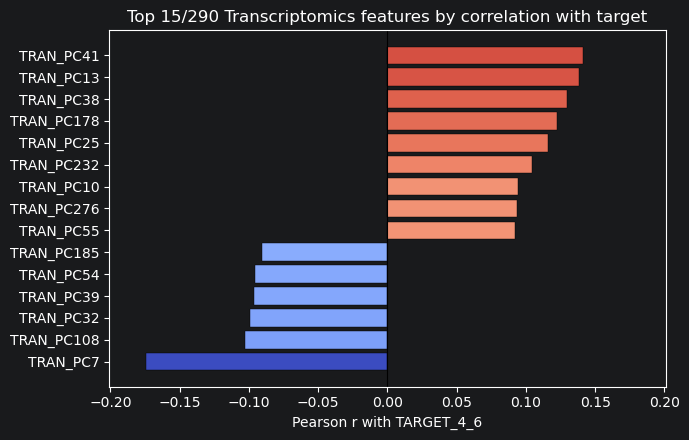

In [12]:
num_to_show = 15
tran_corrs = df_tran[tran_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

top = tran_corrs.loc[tran_corrs.abs().sort_values(ascending=False).head(num_to_show).index]
top = top.sort_values()  # ascending so largest positive lands at top of barh

vmax = top.abs().max()
colors = plt.cm.coolwarm((top.values / vmax + 1) / 2)

fig, ax = plt.subplots(figsize=(7, max(4, num_to_show * 0.3)))
ax.barh(top.index, top.values, color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Pearson r with {TARGET_COL}')
ax.set_title(f'Top {num_to_show}/{len(tran_cols)} Transcriptomics features by correlation with target')
ax.set_xlim(-vmax * 1.15, vmax * 1.15)
plt.tight_layout()
plt.show()

### Drop sparse features

Drop columns missing in more than MISSING_THRESHOLD of rows — they're too gappy for models to learn from and slow training enough that tree models time out

In [13]:
miss_frac = df.isna().mean()
sparse_cols = miss_frac[miss_frac > MISSING_THRESHOLD].index

if FORCE_KEEP_TRANSCRIPTOMICS:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL and c not in tran_cols]
else:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL]

df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 91 columns with >90% missing.
Shape: (3705, 399)


In [14]:
surviving_tran = [c for c in df.columns if c.startswith('TRAN_')]
print(f'TRAN columns surviving sparse filter: {len(surviving_tran)} / {len(tran_cols)}')

TRAN columns surviving sparse filter: 290 / 290


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365 measurements don't exist for them yet (those are what we're being asked to predict). If we leave other `_d28` / `_d365` columns in the feature set, the model will learn to lean on them during training, but at predict time they'll all be NaN for the challenge data. Drop them all, keeping only `TARGET_COL`.

In [15]:
other_target_cols = [c for c in df.columns
                     if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
df = df.drop(columns=other_target_cols)
print(f'Dropped {len(other_target_cols)} other-task target columns.')
print(f'Final shape: {df.shape}')

Dropped 60 other-task target columns.
Final shape: (3705, 339)


In [16]:
# Force float64 on all remaining HAI feature columns to prevent H2O from mistyping
# sparsely-populated columns as categorical, which crashes predict() on the challenge set.
hai_feature_cols = [c for c in df.columns if c.startswith('HAI_') and c != TARGET_COL]
for c in hai_feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Forced float64 on {len(hai_feature_cols)} HAI feature columns in training and challenge data.')

Forced float64 on 44 HAI feature columns in training and challenge data.


In [17]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats:\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (3705, 339)
Target (TARGET_4_6) stats:
count    3705.000000
mean        0.626608
std         0.324879
min         0.000000
25%         0.395833
50%         0.666667
75%         0.933333
max         1.000000
Name: TARGET_4_6, dtype: float64

dtype counts:
float64    336
str          3
Name: count, dtype: int64


---
## AutoML Setup

In [18]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.1" 2026-04-21; OpenJDK Runtime Environment Homebrew (build 26.0.1); OpenJDK 64-Bit Server VM Homebrew (build 26.0.1, mixed mode, sharing)
  Starting server from /Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpev4913ag
  JVM stdout: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpev4913ag/h2o_chayan_started_from_python.out
  JVM stderr: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpev4913ag/h2o_chayan_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 19 days
H2O_cluster_name:,H2O_from_python_chayan_nhnmlo
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.98 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


In [19]:
hai_col_types = {c: 'real' for c in hai_feature_cols}
tran_col_types = {c: 'real' for c in surviving_tran}
col_types = {**hai_col_types, **tran_col_types}
data = h2o.H2OFrame(df, column_types=col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (3705, 339)


---
## AutoML Training

In [20]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(
    max_models=AUTOML_MAX_MODELS,
    seed=AUTOML_SEED,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS
)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 3705  |  Features: 337
Training complete.


In [21]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,GBM_4_AutoML_1_20260531_190349,0.191840,0.036803,0.137546,0.127679,0.036803
1,GBM_2_AutoML_1_20260531_190349,0.193318,0.037372,0.140329,0.129039,0.037372
2,GBM_3_AutoML_1_20260531_190349,0.193403,0.037405,0.140289,0.128976,0.037405
3,GBM_5_AutoML_1_20260531_190349,0.194816,0.037953,0.141090,0.129791,0.037953
4,GBM_1_AutoML_1_20260531_190349,0.196801,0.038731,0.144271,0.131646,0.038731
5,DRF_1_AutoML_1_20260531_190349,0.196815,0.038736,0.143753,0.130819,0.038736
6,XRT_1_AutoML_1_20260531_190349,0.198854,0.039543,0.147289,0.132407,0.039543
7,DeepLearning_1_AutoML_1_20260531_190349,0.243227,0.059159,0.182964,0.162817,0.059159
8,GLM_1_AutoML_1_20260531_190349,0.273279,0.074682,0.226270,0.185883,0.074682


In [22]:
# Best overall (may be a StackedEnsemble) — used for predictions and saved as the deliverable
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

# Best non-ensemble — used for Spearman CV and varimp, since StackedEnsembles don't expose
# cross-validation holdout predictions in the same way base models do.
top_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_base_model = h2o.get_model(top_base_model_id)

cv_preds = top_base_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actuals = data[y].as_data_frame(use_multi_thread=True)[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Prediction model:  {top_model.model_id}')
print(f'Scoring model:     {top_base_model.model_id}')
print(f'Task 4.6 — Spearman (best base model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Prediction model:  GBM_4_AutoML_1_20260531_190349
Scoring model:     GBM_4_AutoML_1_20260531_190349
Task 4.6 — Spearman (best base model 5-fold CV): 0.773  (p=0.0000)


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Best base model: GBM_4_AutoML_1_20260531_190349


,variable,relative_importance,scaled_importance,percentage
0,HAI_Yam B/Florida/4/2006_d0,340.130371,1.000000,0.232736
1,HAI_H1N1 A/California/7/2009_d0,221.002380,0.649758,0.151222
2,PART_age,119.801414,0.352222,0.081975
3,HAI_Vic B/Brisbane/60/2008_d0,81.935074,0.240893,0.056064
4,HAI_H1N1 A/Brisbane/59/2007_d0,80.049767,0.235350,0.054774
5,HAI_H3N2 A/Perth/16/2009_d0,75.022697,0.220570,0.051335
6,HAI_H3N2 A/South Australia/34/2019_d0,64.506027,0.189651,0.044139
7,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,41.916958,0.123238,0.028682
8,HAI_H3N2 A/Victoria/361/2011_d0,40.706619,0.119679,0.027854
9,HAI_H3N2 A/Uruguay/716/2007_d0,39.446499,0.115975,0.026991


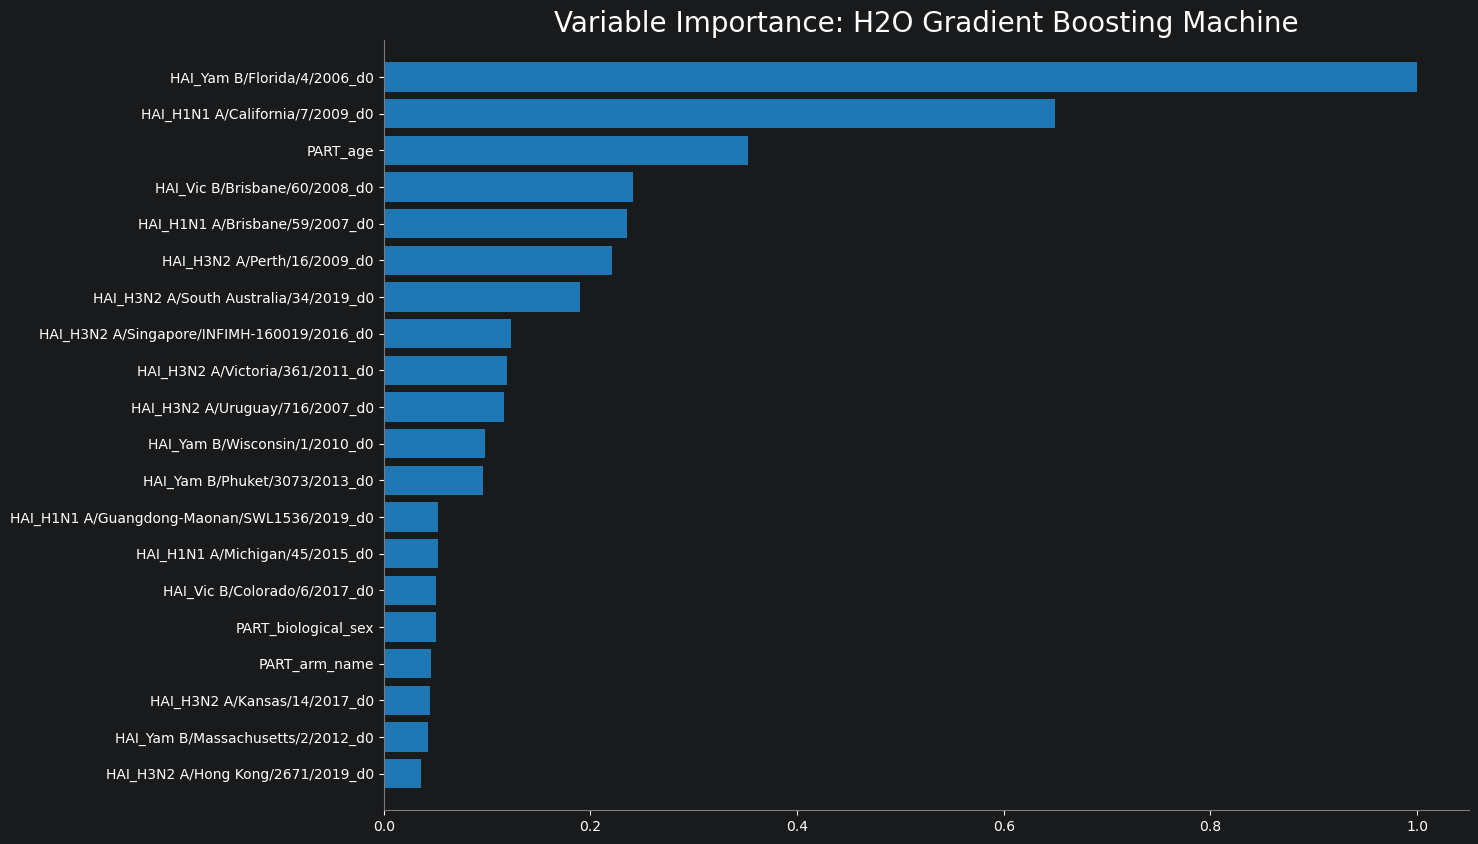

<Figure size 640x480 with 0 Axes>

In [23]:
print(f'Best base model: {top_base_model.model_id}')
varimp = top_base_model.varimp(use_pandas=True)
display(varimp.head(20))
top_base_model.varimp_plot(num_of_features=20)

In [24]:
challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_col_types.update({c: 'real' for c in surviving_tran if c in challenge_data.columns})
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.6': y_pred,  # fraction — no inverse transform
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_6.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Participant_ID,Task_4.6
0,2024_UGA.ID_077,0.482627
1,2024_UGA.ID_086,0.692565
2,2024_UGA.ID_128,0.844731
3,2024_UGA.ID_170,0.517293
4,2024_UGA.ID_179,0.425475
5,2024_UGA.ID_215,0.696557
6,2024_UGA.ID_219,0.675456
7,2024_UGA.ID_275,0.474527
8,2024_UGA.ID_295,0.444601
9,2024_UGA.ID_296,0.335638


In [25]:
model_path = h2o.save_model(model=top_model, path='.', filename='models/model_4.6', force=True)
print(f'Model saved to: {model_path}')

Model saved to: /Users/chayan/repos/ucsd/cmi-flu-prediction-challenge-capstone/automl_models/models/model_4.6


In [26]:
h2o.cluster().shutdown()

H2O session _sid_baf0 closed.


---
## Conclusion

- **Leader model:** StackedEnsemble_AllModels (used for challenge predictions)
- **Scoring model:** GBM_4 (best non-ensemble base, used for CV Spearman)
- **CV Spearman:** 0.773 (p < 0.0001)
- **Training samples:** 3,705 | **Features:** 337
- **Model saved:** `automl_models/model_4.6`

**Target:** fraction of measured HAI variants where raw titer ≥ 40 at D28. Predictions are saved directly as fractions (no `exp2`). All 40 challenge predictions fall in [0.16, 0.89] — no negative values unlike the baseline linear model.

**Feature set:** 3 demographics + 44 HAI d0/d7 columns + 290 TRAN columns, after dropping columns >90% missing and all d28/d365 leakage columns. All 290 transcriptomics features survived the sparse filter at this threshold (only ~10.6% of participants have TRAN data, so the threshold has to be high to retain them). All TRAN columns are explicitly typed `real` on both the training and challenge H2OFrames — without that, H2O's auto-type heuristic flags sparsely-populated PCs as categorical during training, then crashes `predict()` against the fully-populated challenge frame.

**Challenge transcriptomics:** all 40 challenge participants have TRAN PCs merged in (via `challenge_transcriptomics_cleaned.csv` joined on `participant_id`), so the model uses real PC values at inference time instead of routing every challenge row down the NA branch of every tree split.

**Imputation note:** No manual imputation is applied. H2O's tree models (GBM, XRT, DRF) handle `NaN` natively at each split during training and prediction, including inside CV folds — eliminating any leakage that would arise from pre-computing medians on the full training set.

Submission saved to `automl_submission/task_4_6.csv`.

To reload the model: `h2o.load_model('automl_models/model_4.6')`